#Diabetes Prediction project

Dataset link: https://www.kaggle.com/datasets/mathchi/diabetes-data-set

##Load the dataset into Pandas Dataframe

In [ ]:
import pandas as pd
df = pd.read_csv("/content/diabetes.csv")

##Data exploration


In [ ]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
df.shape

(768, 9)

In [ ]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


check for missing values

In [ ]:
df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


check for duplicates

In [ ]:
print(df.duplicated().sum())

0


 Descriptive statistics

In [ ]:
df.describe(include="all")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


##Data processing

Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Outcome'], axis=1)
Y = df['Outcome']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=4)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


Normalize or scale numerical data:

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

In [ ]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-1.132974,-1.705450,0.383767,-1.271984,-0.708493,1.637278,-0.836967,1.091384
1,-0.836702,-1.291495,-0.691949,-1.271984,-0.708493,-1.553728,-0.644604,-1.040008
2,-0.540431,-0.495428,0.332543,-1.271984,-0.708493,-1.042193,0.263109,1.688173
3,-0.540431,-0.973068,-0.435826,-1.271984,-0.708493,-1.017834,-0.845984,-0.698985
4,0.940928,0.141425,0.896013,-1.271984,-0.708493,0.699463,-0.506343,1.517662


In [ ]:
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [ ]:
X_test.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.836702,-0.654642,-0.128479,0.537760,1.005919,0.017416,-0.085549,0.750361
1,1.533472,-2.023876,0.588666,1.037000,-0.708493,0.114851,-1.131523,0.665105
2,-1.132974,-0.654642,0.076420,0.350545,-0.271143,-0.128737,0.374319,-1.040008
3,-0.836702,-0.049631,0.998463,1.286620,0.778497,1.637278,0.103808,-0.613730
4,-0.540431,-0.590956,0.896013,0.974595,0.341147,1.661637,-1.038347,-0.869497


##Model Training

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_classifier =  DecisionTreeClassifier(random_state=33)
dt_classifier.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=33)

##Model evaluating

In [ ]:
y_pred_train = dt_classifier.predict(X_train)
y_pred = dt_classifier.predict(X_test)

Accuracy:

In [ ]:
from sklearn.metrics import accuracy_score
print('Accuracy of Decision Tree-Train: ' , accuracy_score(Y_train, y_pred_train))
print('Accuracy of Decision Tree-Test: ', accuracy_score(Y_test, y_pred))

Accuracy of Decision Tree-Train:  1.0
Accuracy of Decision Tree-Test:  0.6818181818181818


Classification report:

In [ ]:
from sklearn.metrics import classification_report
print('classification report: ')
print( classification_report(Y_test, y_pred))

classification report: 
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       102
           1       0.52      0.62      0.57        52

    accuracy                           0.68       154
   macro avg       0.65      0.67      0.66       154
weighted avg       0.70      0.68      0.69       154



Confusion matrix:

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred)
print('confusion matrix: ')
print(cm)

confusion matrix: 
[[73 29]
 [20 32]]


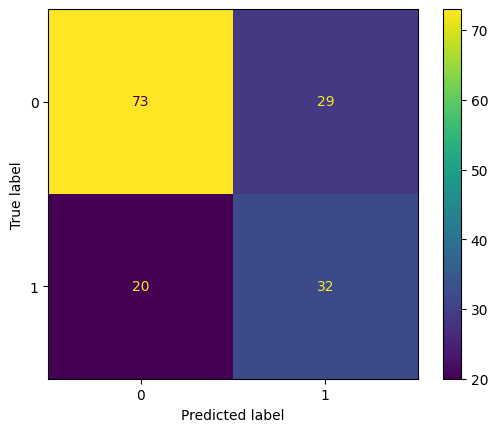

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(cm).plot()

##Model visualization

In [ ]:
from sklearn import tree
text_representation = tree.export_text(dt_classifier)
print(text_representation)

|--- feature_1 <= 0.22
|   |--- feature_7 <= -0.40
|   |   |--- feature_5 <= -0.11
|   |   |   |--- feature_0 <= 1.09
|   |   |   |   |--- feature_6 <= 0.59
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_6 >  0.59
|   |   |   |   |   |--- feature_6 <= 0.64
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_6 >  0.64
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  1.09
|   |   |   |   |--- class: 1
|   |   |--- feature_5 >  -0.11
|   |   |   |--- feature_2 <= -1.61
|   |   |   |   |--- class: 1
|   |   |   |--- feature_2 >  -1.61
|   |   |   |   |--- feature_6 <= 0.08
|   |   |   |   |   |--- feature_5 <= -0.07
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_5 >  -0.07
|   |   |   |   |   |   |--- feature_2 <= 1.31
|   |   |   |   |   |   |   |--- feature_6 <= -1.03
|   |   |   |   |   |   |   |   |--- feature_6 <= -1.08
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- fe

[Text(0.5009884428223844, 0.96875, 'x[1] <= 0.221\ngini = 0.456\nsamples = 614\nvalue = [398, 216]'),
 Text(0.22065085158150852, 0.90625, 'x[7] <= -0.401\ngini = 0.333\nsamples = 393\nvalue = [310, 83]'),
 Text(0.3608196472019465, 0.9375, 'True  '),
 Text(0.0705596107055961, 0.84375, 'x[5] <= -0.11\ngini = 0.152\nsamples = 218\nvalue = [200, 18]'),
 Text(0.029197080291970802, 0.78125, 'x[0] <= 1.089\ngini = 0.031\nsamples = 125\nvalue = [123, 2]'),
 Text(0.019464720194647202, 0.71875, 'x[6] <= 0.588\ngini = 0.016\nsamples = 124\nvalue = [123, 1]'),
 Text(0.009732360097323601, 0.65625, 'gini = 0.0\nsamples = 108\nvalue = [108, 0]'),
 Text(0.029197080291970802, 0.65625, 'x[6] <= 0.643\ngini = 0.117\nsamples = 16\nvalue = [15, 1]'),
 Text(0.019464720194647202, 0.59375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.038929440389294405, 0.59375, 'gini = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.038929440389294405, 0.71875, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.1119221

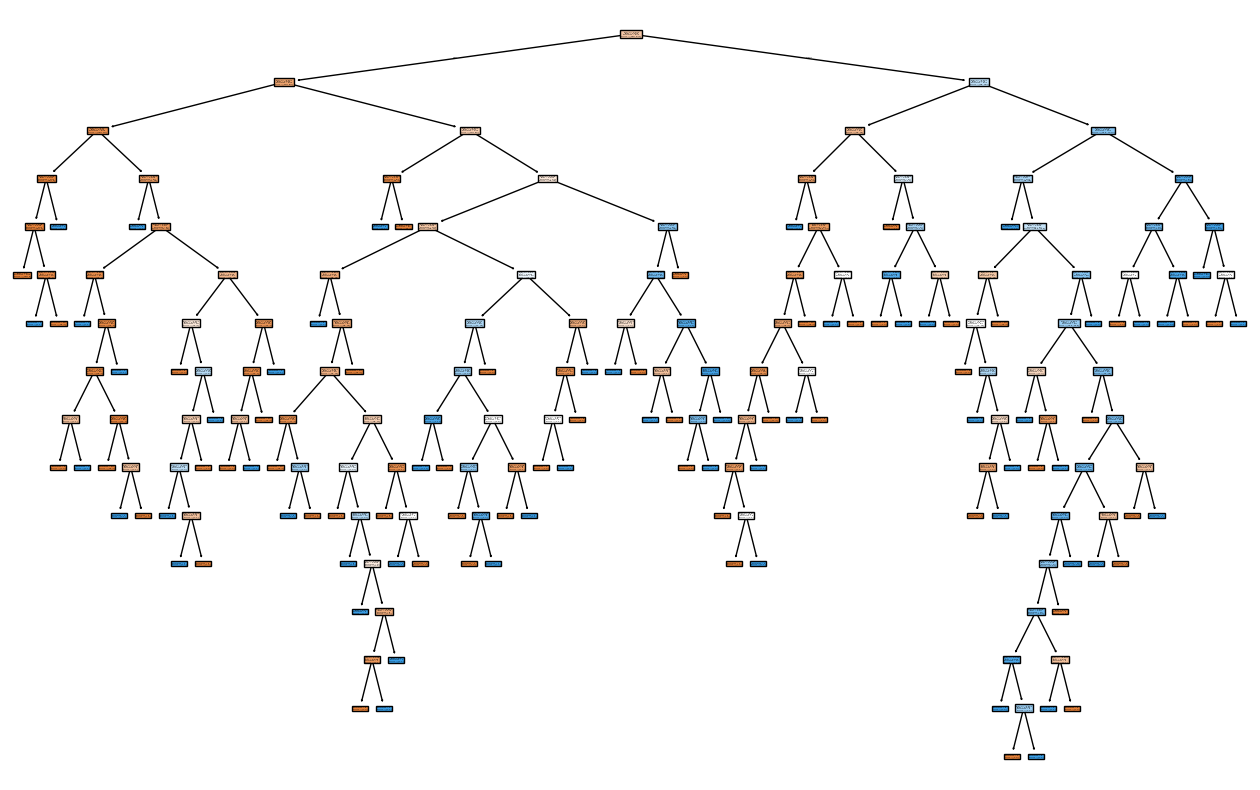

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(16,10))
tree.plot_tree(dt_classifier, filled = True)


##Hyperparameter Tuning:

In [ ]:
import numpy as np
def tree_depth_tuning(d):
  dt_classifier = DecisionTreeClassifier(max_depth=d,random_state=33)
  dt_classifier.fit(X_train, Y_train)
  y_pred = dt_classifier.predict(X_test)
  accuracy = accuracy_score(Y_test, y_pred)
  return accuracy
tree_result = pd.DataFrame({'D':np.arange(1,20)})
tree_result['accuracy']= tree_result['D'].apply(tree_depth_tuning)
tree_result

,D,accuracy
0,1,0.792208
1,2,0.805195
2,3,0.811688
3,4,0.785714
4,5,0.772727
5,6,0.772727
6,7,0.740260
7,8,0.733766
8,9,0.694805
9,10,0.701299


##Final Model

In [ ]:
dt_classifier =  DecisionTreeClassifier(max_depth=3,random_state=33)
dt_classifier.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=3, random_state=33)

In [ ]:
y_pred_train = dt_classifier.predict(X_train)
y_pred = dt_classifier.predict(X_test)
print('Accuracy of Decision Tree-Train: ', accuracy_score(Y_train, y_pred_train))
print('Accuracy of Decision Tree-Test: ', accuracy_score(Y_test, y_pred))

Accuracy of Decision Tree-Train:  0.7671009771986971
Accuracy of Decision Tree-Test:  0.8116883116883117


In [ ]:
cm = confusion_matrix(Y_test, y_pred)
cr = classification_report(Y_test, y_pred)

print('confusion matrix: ')
print(cm)
print('classification report: ')
print(cr)

confusion matrix: 
[[86 16]
 [13 39]]
classification report: 
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       102
           1       0.71      0.75      0.73        52

    accuracy                           0.81       154
   macro avg       0.79      0.80      0.79       154
weighted avg       0.81      0.81      0.81       154



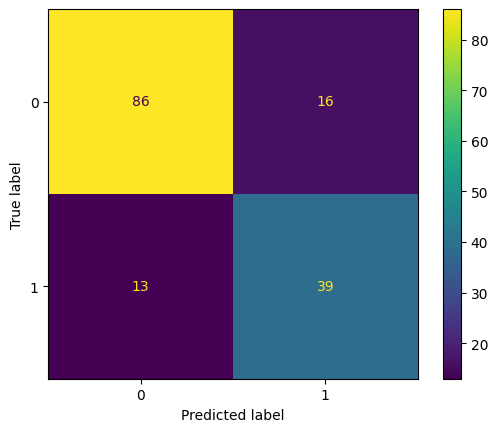

In [ ]:
ConfusionMatrixDisplay(cm).plot()

In [ ]:
text_representation = tree.export_text(dt_classifier)
print(text_representation)

|--- feature_1 <= 0.22
|   |--- feature_7 <= -0.40
|   |   |--- feature_5 <= -0.11
|   |   |   |--- class: 0
|   |   |--- feature_5 >  -0.11
|   |   |   |--- class: 0
|   |--- feature_7 >  -0.40
|   |   |--- feature_5 <= -0.62
|   |   |   |--- class: 0
|   |   |--- feature_5 >  -0.62
|   |   |   |--- class: 0
|--- feature_1 >  0.22
|   |--- feature_5 <= -0.23
|   |   |--- feature_1 <= 0.99
|   |   |   |--- class: 0
|   |   |--- feature_1 >  0.99
|   |   |   |--- class: 1
|   |--- feature_5 >  -0.23
|   |   |--- feature_1 <= 1.43
|   |   |   |--- class: 1
|   |   |--- feature_1 >  1.43
|   |   |   |--- class: 1



[Text(0.5, 0.875, 'x[1] <= 0.221\ngini = 0.456\nsamples = 614\nvalue = [398, 216]'),
 Text(0.25, 0.625, 'x[7] <= -0.401\ngini = 0.333\nsamples = 393\nvalue = [310, 83]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[5] <= -0.11\ngini = 0.152\nsamples = 218\nvalue = [200, 18]'),
 Text(0.0625, 0.125, 'gini = 0.031\nsamples = 125\nvalue = [123, 2]'),
 Text(0.1875, 0.125, 'gini = 0.285\nsamples = 93\nvalue = [77, 16]'),
 Text(0.375, 0.375, 'x[5] <= -0.616\ngini = 0.467\nsamples = 175\nvalue = [110, 65]'),
 Text(0.3125, 0.125, 'gini = 0.111\nsamples = 34\nvalue = [32, 2]'),
 Text(0.4375, 0.125, 'gini = 0.494\nsamples = 141\nvalue = [78, 63]'),
 Text(0.75, 0.625, 'x[5] <= -0.232\ngini = 0.479\nsamples = 221\nvalue = [88, 133]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[1] <= 0.985\ngini = 0.417\nsamples = 64\nvalue = [45, 19]'),
 Text(0.5625, 0.125, 'gini = 0.298\nsamples = 44\nvalue = [36, 8]'),
 Text(0.6875, 0.125, 'gini = 0.495\nsamples = 20\nvalue = [9, 11]'),
 Text(

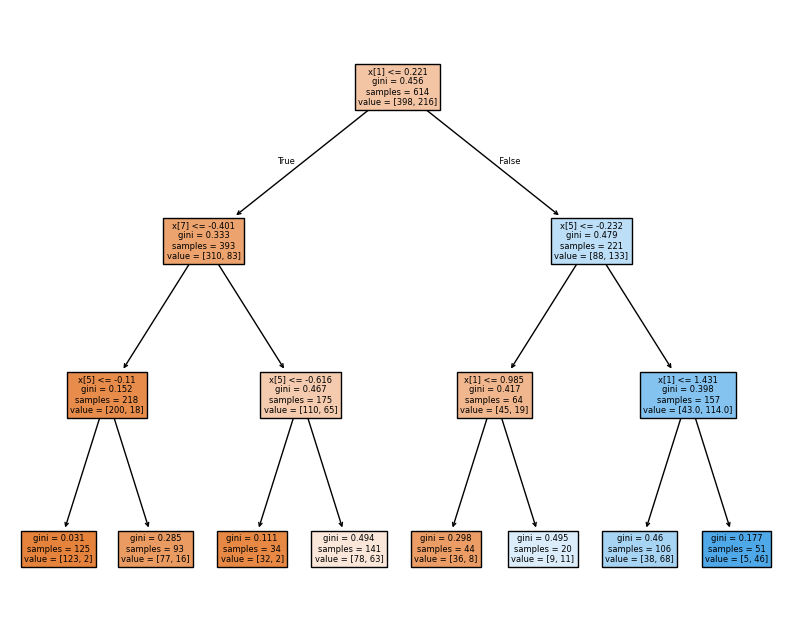

In [ ]:
plt.figure(figsize=(10,8))
tree.plot_tree(dt_classifier, filled = True)